### !!!! COMMENT TOXICITY DETECTION !!!

##### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd                      # For data handling
import numpy as np                       # For numerical operations

import matplotlib.pyplot as plt          # For plotting
import seaborn as sns                    # For better visualizations

import re                                # For text cleaning
import nltk                              # NLP library
from nltk.corpus import stopwords        # Stopwords

from sklearn.model_selection import train_test_split   # Split data
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    multilabel_confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout,
    SpatialDropout1D, Input, LSTM, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import pickle                            # To save tokenizer
import os                                # File handling

import warnings
warnings.filterwarnings("ignore")        # Ignore warnings

##### 2. LOAD DATASET

In [2]:
train_df = pd.read_csv(r"C:\Users\KAVIYA V\Downloads\train.csv")
test_df  = pd.read_csv(r"C:\Users\KAVIYA V\Downloads\test.csv")

Train shape: (159571, 8)
Test shape : (153164, 2)


##### 3. Exploratory Data Analysis (EDA)

In [ ]:
# Display first few rows
print("Train Data Preview:")
print(train_df.head())

print("\nTest Data Preview:")
print(test_df.head())

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

In [ ]:
print("Train Info:")
print(train_df.info())

print("\nTest Info:")
print(test_df.info())

In [ ]:
print("Train Data Types:")
print(train_df.dtypes)

print("\nTest Data Types:")
print(test_df.dtypes)

In [ ]:
print("Train Describe:")
print(train_df.describe())

print("\nTest Describe:")
print(test_df.describe())

In [3]:
print("Train Missing Values:")
print(train_df.isnull().sum())

print("\nTest Missing Values:")
print(test_df.isnull().sum())


Missing values (Train):
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


##### 4. LABEL COLUMNS

In [4]:
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

##### 5. LABEL DISTRIBUTION VISUALIZATION

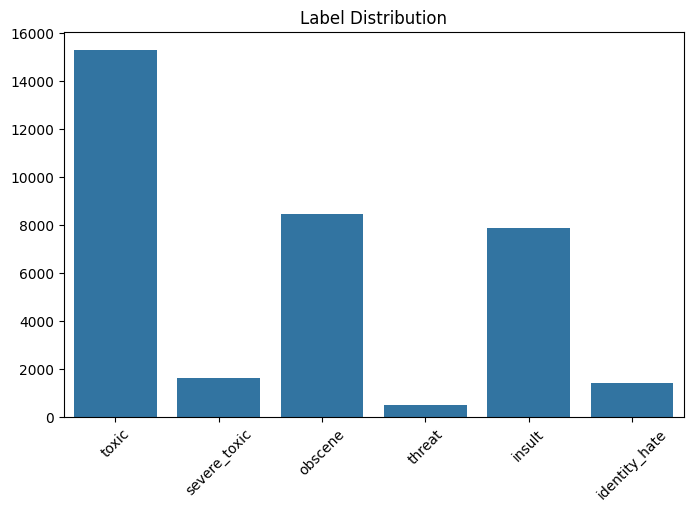

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x=label_cols, y=train_df[label_cols].sum().values)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.show()

##### 6. TEXT CLEANING

In [6]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                 # Convert to lowercase
    text = re.sub(r'http\S+', '', text)      # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)     # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    
    words = text.split()                     # Tokenize
    words = [w for w in words if w not in stop_words]  # Remove stopwords
    
    return " ".join(words)


# Apply cleaning
train_df['comment_text'] = train_df['comment_text'].fillna("").apply(clean_text)

[nltk_data] Downloading package stopwords to C:\Users\KAVIYA
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### 7. REMOVE DUPLICATES

In [7]:
train_df.drop_duplicates(subset=['comment_text'], inplace=True)
train_df.reset_index(drop=True, inplace=True)

##### 8. TOKENIZATION + PADDING

In [8]:
MAX_WORDS = 20000   # Vocabulary size
MAX_LEN = 150       # Sequence length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['comment_text'])

# Convert text → sequences
X = tokenizer.texts_to_sequences(train_df['comment_text'])

# Pad sequences
X = pad_sequences(X, maxlen=MAX_LEN)

# Labels
y = train_df[label_cols].values

##### 9. TRAIN-VALIDATION SPLIT

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("Train shape:", X_tr.shape)
print("Val shape  :", X_val.shape)

Train shape: (142010, 150)
Val shape  : (15779, 150)


##### 10. CNN MODEL

In [20]:
cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS, 128),
    
    SpatialDropout1D(0.4),          # Increased dropout
    
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    
    Dense(128, activation='relu'),  # Increased neurons
    Dropout(0.4),
    
    Dense(6, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]   # Better metric
)

##### 11. LSTM MODEL

In [21]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS, 128),
    
    SpatialDropout1D(0.3),
    
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(6, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

##### 11. TRAIN MODELS

In [22]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("\nTraining CNN...")
cnn_model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=10,              # Increased epochs
              batch_size=128,
              callbacks=[callback])

print("\nTraining LSTM...")
lstm_model.fit(X_tr, y_tr,
               validation_data=(X_val, y_val),
               epochs=10,
               batch_size=128,
               callbacks=[callback])


Training CNN...
Epoch 1/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - auc: 0.9435 - loss: 0.0799 - val_auc: 0.9801 - val_loss: 0.0516
Epoch 2/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - auc: 0.9805 - loss: 0.0494 - val_auc: 0.9804 - val_loss: 0.0498
Epoch 3/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 73s 66ms/step - auc: 0.9868 - loss: 0.0427 - val_auc: 0.9784 - val_loss: 0.0496
Epoch 4/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 75s 68ms/step - auc: 0.9902 - loss: 0.0369 - val_auc: 0.9700 - val_loss: 0.0530
Epoch 5/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 74s 67ms/step - auc: 0.9924 - loss: 0.0324 - val_auc: 0.9676 - val_loss: 0.0553

Training LSTM...
Epoch 1/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 607s 544ms/step - auc: 0.9414 - loss: 0.0814 - val_auc: 0.9818 - val_loss: 0.0490
Epoch 2/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 440s 396ms/step - auc: 0.9807 - loss: 0.0488 - val_auc: 0.9831 - val_loss: 0.0486
Epoch 3/10
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 400s 360ms/step - auc: 0.9848 - loss: 0.0446 - val_auc: 0.9782 - 

##### 12. PREDICTIONS

In [23]:
cnn_pred = cnn_model.predict(X_val)
lstm_pred = lstm_model.predict(X_val)

494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step


##### 13. AUC COMPARISON

In [24]:
cnn_auc = roc_auc_score(y_val, cnn_pred)
lstm_auc = roc_auc_score(y_val, lstm_pred)

print(f"\nCNN AUC  : {cnn_auc:.4f}")
print(f"LSTM AUC : {lstm_auc:.4f}")


CNN AUC  : 0.9741
LSTM AUC : 0.9739


##### 14. CLASSIFICATION REPORT

In [25]:
cnn_bin = (cnn_pred > 0.5).astype(int)

print("\nCNN Classification Report:\n")
print(classification_report(y_val, cnn_bin, target_names=label_cols))


CNN Classification Report:

               precision    recall  f1-score   support

        toxic       0.78      0.78      0.78      1499
 severe_toxic       0.52      0.42      0.47       170
      obscene       0.84      0.83      0.83       870
       threat       0.00      0.00      0.00        47
       insult       0.73      0.71      0.72       787
identity_hate       0.00      0.00      0.00       132

    micro avg       0.77      0.72      0.74      3505
    macro avg       0.48      0.46      0.47      3505
 weighted avg       0.73      0.72      0.72      3505
  samples avg       0.07      0.07      0.06      3505



##### 15. CONFUSION MATRIX

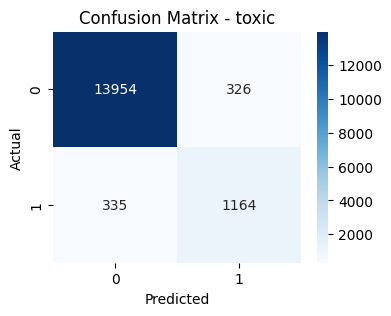

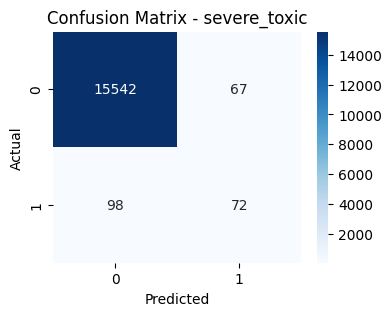

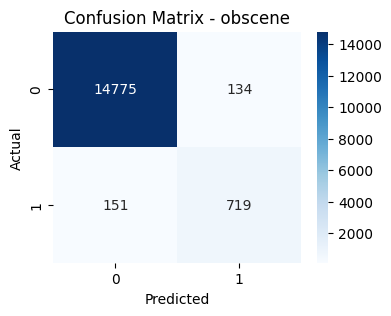

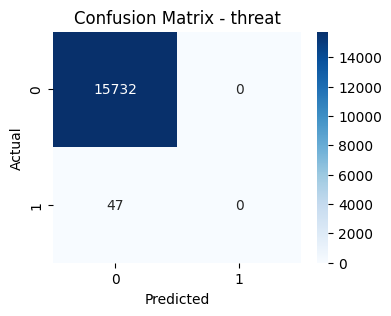

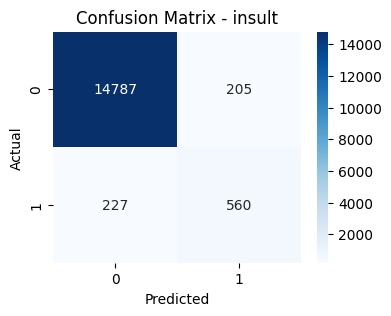

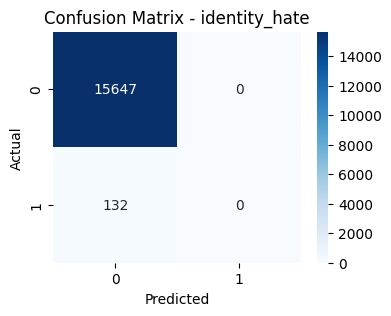

In [26]:
cm = multilabel_confusion_matrix(y_val, cnn_bin)

for i, label in enumerate(label_cols):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

##### 16. SELECT BEST MODEL

In [32]:
best_model = cnn_model if cnn_auc > lstm_auc else lstm_model

print("\nBest Model:",
      "CNN" if cnn_auc > lstm_auc else "LSTM")


Best Model: CNN


##### 17. SAVE MODEL + TOKENIZER

In [36]:
os.makedirs("toxicity_model", exist_ok=True)

best_model.save("toxicity_model/best_model.keras")

pickle.dump(tokenizer, open("toxicity_model/tokenizer.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


##### 18. PREDICTION FUNCTION 

In [37]:
def predict_toxicity(text):
    text = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    pred = best_model.predict(padded)[0]

    result = {}
    for label, prob in zip(label_cols, pred):
        prob = float(prob)

        result[label] = {
            "probability": round(prob, 3),
            "label": "Toxic" if prob > 0.3 else "Non-Toxic"   # 🔥 changed
        }

    return result

##### 19. TEST SAMPLE

In [38]:
sample = "You are a horrible person"
print("\nSample Prediction:")
print(predict_toxicity(sample))


Sample Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{'toxic': {'probability': 0.174, 'label': 'Non-Toxic'}, 'severe_toxic': {'probability': 0.0, 'label': 'Non-Toxic'}, 'obscene': {'probability': 0.014, 'label': 'Non-Toxic'}, 'threat': {'probability': 0.002, 'label': 'Non-Toxic'}, 'insult': {'probability': 0.023, 'label': 'Non-Toxic'}, 'identity_hate': {'probability': 0.004, 'label': 'Non-Toxic'}}
